In [33]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName('my spark app for users') \
    .config('spark.some.config.option' , 'somev-alue') \
    .getOrCreate()


print(spark)

In [59]:
df = spark.read.csv('person_data.csv' , header=True , inferSchema=True)

In [60]:
df.show()

+---------+----------+---------+-----------+---------+------+---+------+---------+-------------+---------+--------------+---------------+------+
|RowNumber|CustomerId|  Surname|CreditScore|Geography|Gender|Age|Tenure|  Balance|NumOfProducts|HasCrCard|IsActiveMember|EstimatedSalary|Exited|
+---------+----------+---------+-----------+---------+------+---+------+---------+-------------+---------+--------------+---------------+------+
|        1|  15634602| Hargrave|        619|   France|Female| 42|     2|      0.0|            1|        1|             1|      101348.88|     1|
|        2|  15647311|     Hill|        608|    Spain|Female| 41|     1| 83807.86|            1|        0|             1|      112542.58|     0|
|        3|  15619304|     Onio|        502|   France|Female| 42|     8| 159660.8|            3|        1|             0|      113931.57|     1|
|        4|  15701354|     Boni|        699|   France|Female| 39|     1|      0.0|            2|        0|             0|       93

In [36]:
df.printSchema()

root
 |-- RowNumber: integer (nullable = true)
 |-- CustomerId: integer (nullable = true)
 |-- Surname: string (nullable = true)
 |-- CreditScore: integer (nullable = true)
 |-- Geography: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Tenure: integer (nullable = true)
 |-- Balance: double (nullable = true)
 |-- NumOfProducts: integer (nullable = true)
 |-- HasCrCard: integer (nullable = true)
 |-- IsActiveMember: integer (nullable = true)
 |-- EstimatedSalary: double (nullable = true)
 |-- Exited: integer (nullable = true)



In [37]:
df.describe().show()

+-------+------------------+-----------------+-------+-----------------+---------+------+------------------+------------------+-----------------+------------------+-------------------+-------------------+-----------------+-------------------+
|summary|         RowNumber|       CustomerId|Surname|      CreditScore|Geography|Gender|               Age|            Tenure|          Balance|     NumOfProducts|          HasCrCard|     IsActiveMember|  EstimatedSalary|             Exited|
+-------+------------------+-----------------+-------+-----------------+---------+------+------------------+------------------+-----------------+------------------+-------------------+-------------------+-----------------+-------------------+
|  count|             10000|            10000|  10000|            10000|    10000| 10000|             10000|             10000|            10000|             10000|              10000|              10000|            10000|              10000|
|   mean|            5000.5|

In [71]:
from pyspark.sql.functions import col, sum, trim

numeric_values = [c for c , type  in df.dtypes if type in ['int' , 'float' , 'double' , 'short'  , 'decimal' ]]

numeric_values

df_null_counts = df.select([
    sum(
        (

            col(c) == 0
          
            
        ).cast("int")
    ).alias(c)
    for c in numeric_values
])

df_null_counts.show()


+---------+----------+-----------+---+------+-------+-------------+---------+--------------+---------------+------+
|RowNumber|CustomerId|CreditScore|Age|Tenure|Balance|NumOfProducts|HasCrCard|IsActiveMember|EstimatedSalary|Exited|
+---------+----------+-----------+---+------+-------+-------------+---------+--------------+---------------+------+
|        0|         0|          0|  0|   413|   3617|            0|     2945|          4849|              0|  7963|
+---------+----------+-----------+---+------+-------+-------------+---------+--------------+---------------+------+



In [81]:
numeric_cols = [c for c, dtype in df.dtypes 
                if dtype in ('int', 'long', 'float', 'double', 'short', 'decimal')]

probabilities = [0.25, 0.5, 0.75]
relative_error = 0.25

quantiles_list = df.approxQuantile(numeric_cols, probabilities, relative_error)


print("Approximate Quantiles (25%, 50%, 75%):")
for col_name, values in zip(numeric_cols, quantiles_list):
    print(f"Column '{col_name}': {values}")

Approximate Quantiles (25%, 50%, 75%):
Column 'RowNumber': [1.0, 2502.0, 10000.0]
Column 'CustomerId': [15565701.0, 15628558.0, 15815690.0]
Column 'CreditScore': [350.0, 584.0, 850.0]
Column 'Age': [18.0, 32.0, 92.0]
Column 'Tenure': [0.0, 3.0, 10.0]
Column 'Balance': [0.0, 0.0, 250898.09]
Column 'NumOfProducts': [1.0, 1.0, 4.0]
Column 'HasCrCard': [0.0, 0.0, 1.0]
Column 'IsActiveMember': [0.0, 0.0, 1.0]
Column 'EstimatedSalary': [11.58, 51016.02, 199992.48]
Column 'Exited': [0.0, 0.0, 1.0]


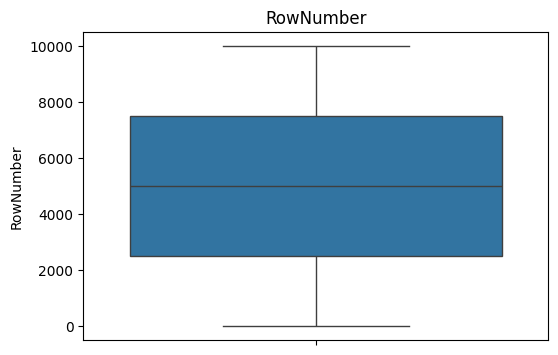

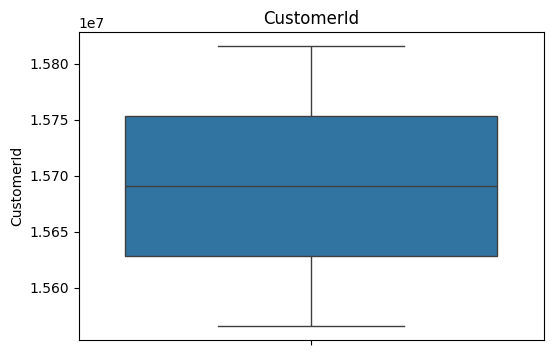

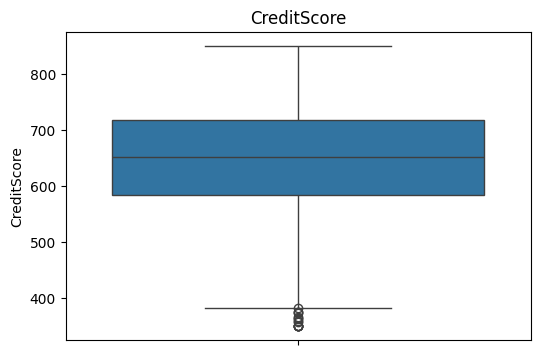

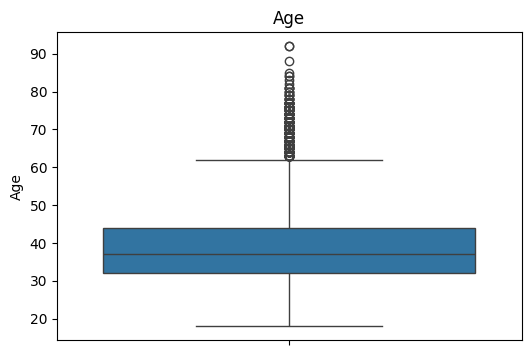

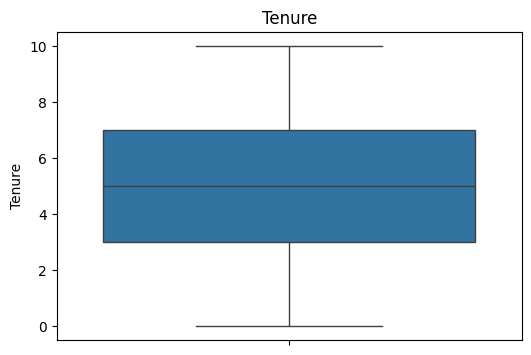

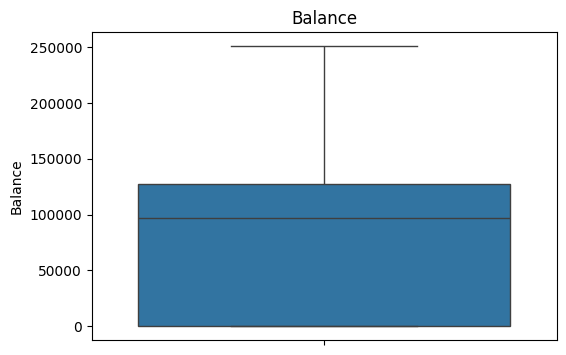

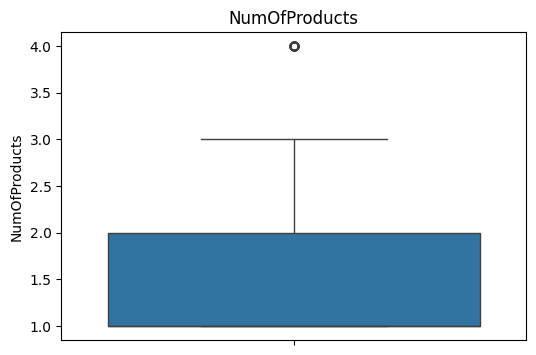

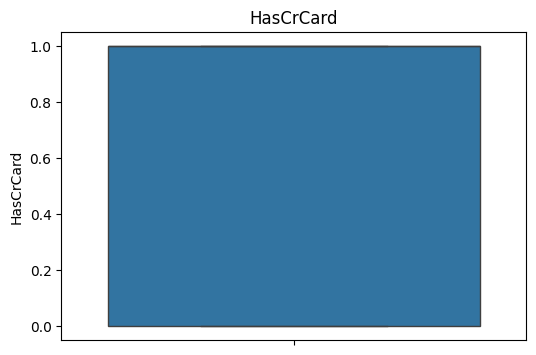

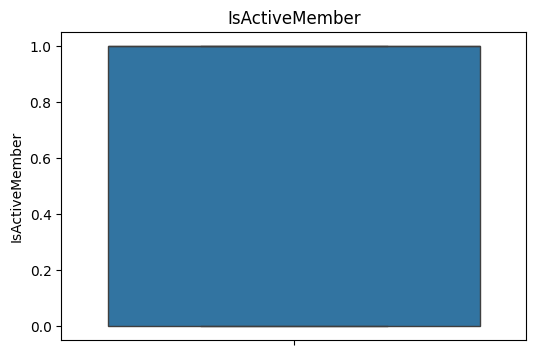

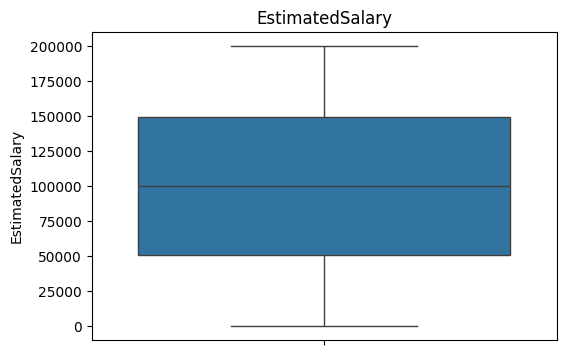

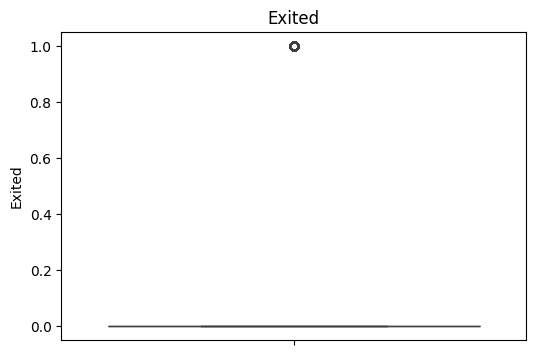

In [86]:
import seaborn as sns 
import matplotlib.pyplot as plt

df_numeric = df.select(numeric_cols).toPandas()


for c in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df_numeric[c])
    plt.title(c)
    plt.show()

